# Credit Card Fraud Detection — Threshold Tuning & Interpretability

Select the operating threshold for the Stage 3 winning configuration and inspect model behavior with feature importance and SHAP.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

from src.features import add_time_features, add_training_volume_feature
from src.preprocessing import make_preprocessor

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
SMOTE_SAMPLING_STRATEGY = 0.10
FP_COST = 1.0
FN_COST = 10.0

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split

## 2. Load the Raw Dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Run this notebook from the project's notebooks directory."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Fraud transactions: {df['Class'].sum():,}")
print(f"Fraud rate: {df['Class'].mean() * 100:.4f}%")


Dataset shape: (284807, 31)
Fraud transactions: 492
Fraud rate: 0.1727%


## 3. Recreate the Stage 3 Train/Test Setup

The same split and feature engineering are reproduced so the notebook can be run independently.

In [3]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_fe = add_time_features(X_train)
X_test_fe = add_time_features(X_test)

X_train_fe, X_test_fe, hourly_counts = add_training_volume_feature(
    X_train_fe,
    X_test_fe,
)

print(f"Training features: {X_train_fe.shape}")
print(f"Testing features:  {X_test_fe.shape}")

Training features: (227845, 35)
Testing features:  (56962, 35)


## 4. Build the Stage 3 Winning Pipeline

Stage 3 selected **LightGBM — SMOTE** by mean cross-validated PR-AUC. The same configuration is rebuilt here; no new model comparison is performed.

In [4]:
best_model_name = "LightGBM — SMOTE"

winning_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

best_pipeline_template = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        (
            "sampler",
            SMOTE(
                sampling_strategy=SMOTE_SAMPLING_STRATEGY,
                random_state=RANDOM_STATE,
            ),
        ),
        ("model", winning_model),
    ]
)

print(f"Leading model: {best_model_name}")

Leading model: LightGBM — SMOTE


## 5. Generate Out-of-Fold Probabilities

Each training observation receives a prediction from a pipeline that did not train on that observation. These probabilities are used for threshold selection.

In [5]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probabilities = cross_val_predict(
    best_pipeline_template,
    X_train_fe,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

oof_pr_auc = average_precision_score(y_train, oof_probabilities)
oof_roc_auc = roc_auc_score(y_train, oof_probabilities)

print(f"OOF PR-AUC:  {oof_pr_auc:.6f}")
print(f"OOF ROC-AUC: {oof_roc_auc:.6f}")

OOF PR-AUC:  0.855905
OOF ROC-AUC: 0.978455


## 6. Precision–Recall Curve and Threshold Trade-off

The default `0.5` threshold is not assumed to be optimal. Precision, recall, and F1 are evaluated across the available probability thresholds.

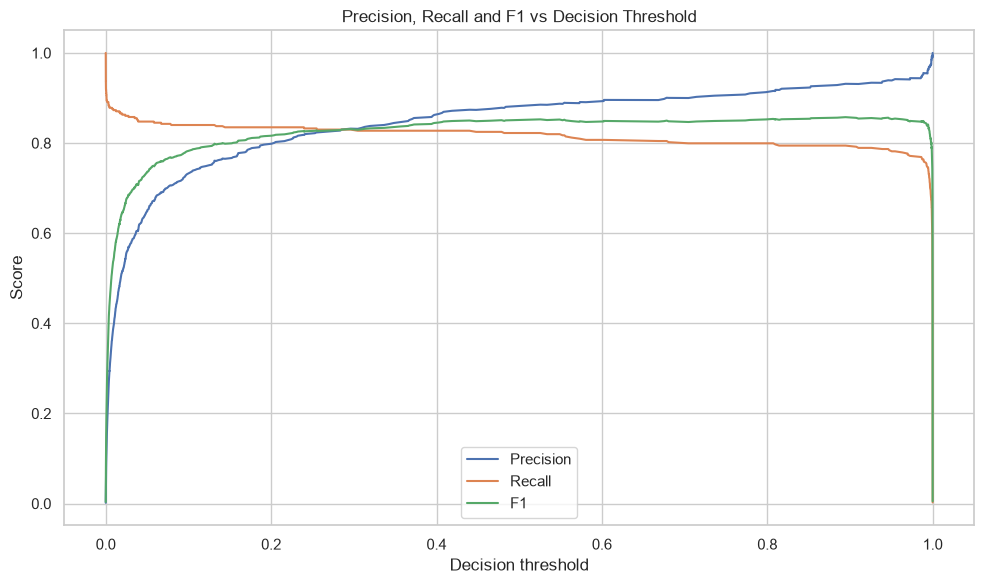

In [6]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_train,
    oof_probabilities,
)

f1_curve = (
    2 * precision_curve[:-1] * recall_curve[:-1]
    / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
)

threshold_metrics = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precision_curve[:-1],
    "recall": recall_curve[:-1],
    "f1": f1_curve,
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_metrics["threshold"], threshold_metrics["precision"], label="Precision")
ax.plot(threshold_metrics["threshold"], threshold_metrics["recall"], label="Recall")
ax.plot(threshold_metrics["threshold"], threshold_metrics["f1"], label="F1")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall and F1 vs Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Business-Cost Threshold Optimization

False positives and false negatives are assigned asymmetric project costs:

- FP = 1
- FN = 10

These are modeling assumptions rather than real monetary estimates.

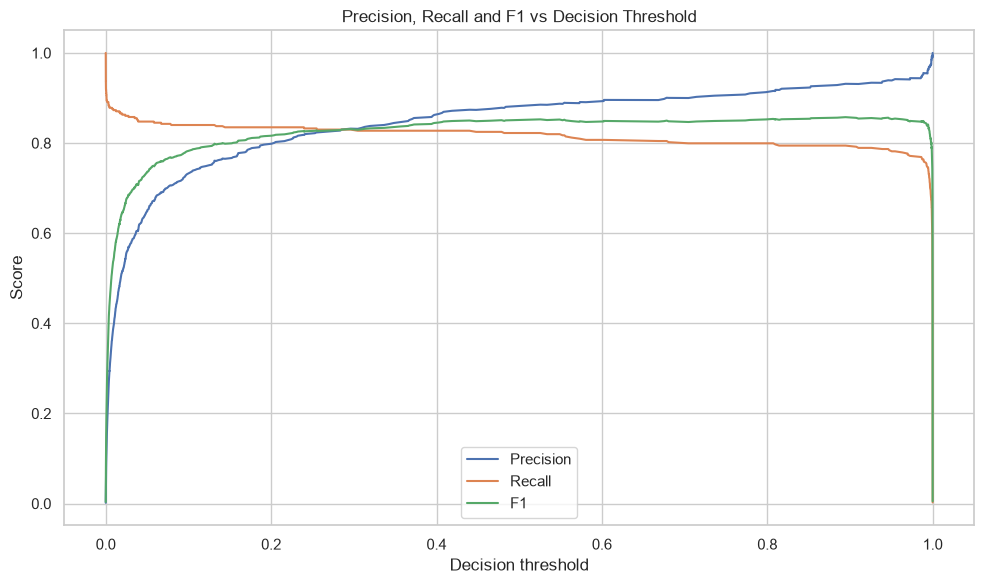

In [7]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_train,
    oof_probabilities,
)

f1_curve = (
    2 * precision_curve[:-1] * recall_curve[:-1]
    / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
)

threshold_metrics = pd.DataFrame({
    "threshold": thresholds_pr,
    "precision": precision_curve[:-1],
    "recall": recall_curve[:-1],
    "f1": f1_curve,
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_metrics["threshold"], threshold_metrics["precision"], label="Precision")
ax.plot(threshold_metrics["threshold"], threshold_metrics["recall"], label="Recall")
ax.plot(threshold_metrics["threshold"], threshold_metrics["f1"], label="F1")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall and F1 vs Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Operational Threshold Constraints

Evaluate alternative operating points using minimum precision and minimum recall constraints.

In [8]:
def threshold_costs(y_true, probabilities, thresholds, fp_cost=1.0, fn_cost=10.0):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities)

    order = np.argsort(-probabilities)
    sorted_probabilities = probabilities[order]
    sorted_labels = y_true[order]

    cumulative_positives = np.cumsum(sorted_labels)
    total_positives = int(y_true.sum())
    total_negatives = len(y_true) - total_positives

    thresholds = np.asarray(thresholds)
    positions = np.searchsorted(
        -sorted_probabilities,
        -thresholds,
        side="left",
    )

    tp = np.where(
        positions > 0,
        cumulative_positives[np.clip(positions - 1, 0, len(y_true) - 1)],
        0,
    )
    fp = positions - tp
    fn = total_positives - tp
    tn = total_negatives - fp

    precision = np.divide(
        tp, tp + fp,
        out=np.zeros_like(tp, dtype=float),
        where=(tp + fp) > 0,
    )
    recall = np.divide(
        tp, tp + fn,
        out=np.zeros_like(tp, dtype=float),
        where=(tp + fn) > 0,
    )
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision),
        where=(precision + recall) > 0,
    )
    cost = fp * fp_cost + fn * fn_cost

    return pd.DataFrame({
        "threshold": thresholds,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cost": cost,
    })

candidate_thresholds = np.linspace(0.001, 0.999, 999)

cost_df = threshold_costs(
    y_train,
    oof_probabilities,
    candidate_thresholds,
    fp_cost=FP_COST,
    fn_cost=FN_COST,
).sort_values("cost").reset_index(drop=True)

display(cost_df.head(10))

cost_optimal_threshold = float(cost_df.iloc[0]["threshold"])

print(f"Cost-optimal threshold: {cost_optimal_threshold:.6f}")
print(f"Minimum estimated OOF cost: {cost_df.iloc[0]['cost']:.0f}")

,threshold,tn,fp,fn,tp,precision,recall,f1,cost
0,0.239,227378,73,65,329,0.818408,0.835025,0.826633,723.0
1,0.236,227378,73,65,329,0.818408,0.835025,0.826633,723.0
2,0.235,227378,73,65,329,0.818408,0.835025,0.826633,723.0
3,0.238,227378,73,65,329,0.818408,0.835025,0.826633,723.0
4,0.237,227378,73,65,329,0.818408,0.835025,0.826633,723.0
5,0.234,227378,73,65,329,0.818408,0.835025,0.826633,723.0
6,0.233,227378,73,65,329,0.818408,0.835025,0.826633,723.0
7,0.231,227377,74,65,329,0.816377,0.835025,0.825596,724.0
8,0.232,227377,74,65,329,0.816377,0.835025,0.825596,724.0
9,0.227,227376,75,65,329,0.814356,0.835025,0.824561,725.0


Cost-optimal threshold: 0.239000
Minimum estimated OOF cost: 723


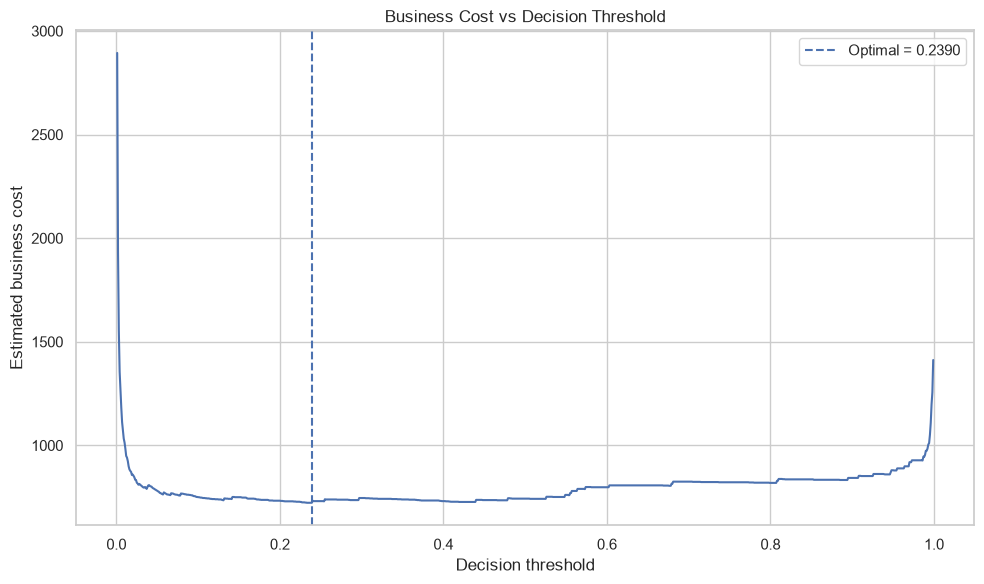

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_df.sort_values("threshold")["threshold"],
        cost_df.sort_values("threshold")["cost"])
ax.axvline(cost_optimal_threshold, linestyle="--",
           label=f"Optimal = {cost_optimal_threshold:.4f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Estimated business cost")
ax.set_title("Business Cost vs Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Operational threshold constraints

Cost is only one way to select an operating point.

For fraud systems, a business may instead specify a minimum acceptable precision or recall.

The following cells provide reusable searches for:
- highest recall while maintaining a minimum precision
- highest precision while maintaining a minimum recall

In [10]:
MIN_PRECISION = 0.50
MIN_RECALL = 0.80

precision_constrained = threshold_metrics[
    threshold_metrics["precision"] >= MIN_PRECISION
].copy()

if len(precision_constrained):
    best_recall_at_precision = precision_constrained.loc[
        precision_constrained["recall"].idxmax()
    ]
    print(
        f"Best recall with precision >= {MIN_PRECISION:.0%}: "
        f"threshold={best_recall_at_precision['threshold']:.6f}, "
        f"precision={best_recall_at_precision['precision']:.4f}, "
        f"recall={best_recall_at_precision['recall']:.4f}"
    )
else:
    print(f"No threshold reaches precision >= {MIN_PRECISION:.0%}.")

recall_constrained = threshold_metrics[
    threshold_metrics["recall"] >= MIN_RECALL
].copy()

if len(recall_constrained):
    best_precision_at_recall = recall_constrained.loc[
        recall_constrained["precision"].idxmax()
    ]
    print(
        f"Best precision with recall >= {MIN_RECALL:.0%}: "
        f"threshold={best_precision_at_recall['threshold']:.6f}, "
        f"precision={best_precision_at_recall['precision']:.4f}, "
        f"recall={best_precision_at_recall['recall']:.4f}"
    )
else:
    print(f"No threshold reaches recall >= {MIN_RECALL:.0%}.")


Best recall with precision >= 50%: threshold=0.018043, precision=0.5000, recall=0.8655
Best precision with recall >= 80%: threshold=0.678352, precision=0.9006, recall=0.8046


## 10. Select the final operating threshold

For this project we use the **business-cost optimum** as the default operating point.

The threshold is chosen from out-of-fold training predictions and is therefore not tuned against the final test set.

In [11]:
FINAL_THRESHOLD = cost_optimal_threshold

print(f"Selected operating threshold: {FINAL_THRESHOLD:.6f}")
print(f"FP cost assumption: {FP_COST}")
print(f"FN cost assumption: {FN_COST}")


Selected operating threshold: 0.239000
FP cost assumption: 1.0
FN cost assumption: 10.0


## 11. Fit the leading model on the complete training set

Only after the threshold has been selected do we fit the final pipeline on all available training data.

In [12]:
best_pipeline = best_pipeline_template.fit(
    X_train_fe,
    y_train,
)

test_probabilities = best_pipeline.predict_proba(X_test_fe)[:, 1]
test_predictions = (test_probabilities >= FINAL_THRESHOLD).astype(int)


## 12. Global Feature Importance

LightGBM's native feature importance is reported using the transformed feature names.

In [13]:
test_pr_auc = average_precision_score(y_test, test_probabilities)
test_roc_auc = roc_auc_score(y_test, test_probabilities)

test_precision = precision_score(
    y_test, test_predictions, zero_division=0
)
test_recall = recall_score(
    y_test, test_predictions, zero_division=0
)
test_f1 = f1_score(
    y_test, test_predictions, zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1],
).ravel()

test_cost = fp * FP_COST + fn * FN_COST

print(f"Model: {best_model_name}")
print(f"Threshold: {FINAL_THRESHOLD:.6f}")
print(f"Test PR-AUC: {test_pr_auc:.6f}")
print(f"Test ROC-AUC: {test_roc_auc:.6f}")
print(f"Test Precision: {test_precision:.6f}")
print(f"Test Recall: {test_recall:.6f}")
print(f"Test F1: {test_f1:.6f}")
print(f"Test Financial Cost: {test_cost:.0f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4,
        zero_division=0,
    )
)

Model: LightGBM — SMOTE
Threshold: 0.239000
Test PR-AUC: 0.874444
Test ROC-AUC: 0.979296
Test Precision: 0.769912
Test Recall: 0.887755
Test F1: 0.824645
Test Financial Cost: 136

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997     56864
           1     0.7699    0.8878    0.8246        98

    accuracy                         0.9994     56962
   macro avg     0.8849    0.9436    0.9122     56962
weighted avg     0.9994    0.9994    0.9994     56962



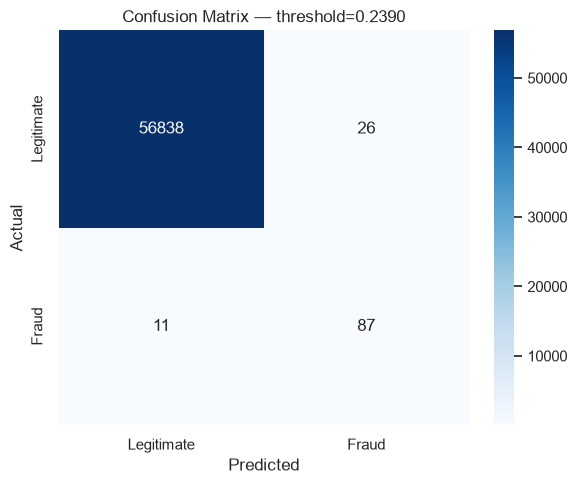

In [14]:
cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — threshold={FINAL_THRESHOLD:.4f}")
plt.tight_layout()
plt.show()


## 13. SHAP Setup

`TreeExplainer` is applied to the fitted LightGBM model after preprocessing. A sample of the test set is used for the SHAP visualizations.

In [15]:
preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

,feature,importance
0,V14,485
1,V4,442
2,Transactions_Per_Hour,359
3,V3,355
4,V24,330
5,V1,329
6,Amount,312
7,V11,302
8,V16,300
9,V12,294


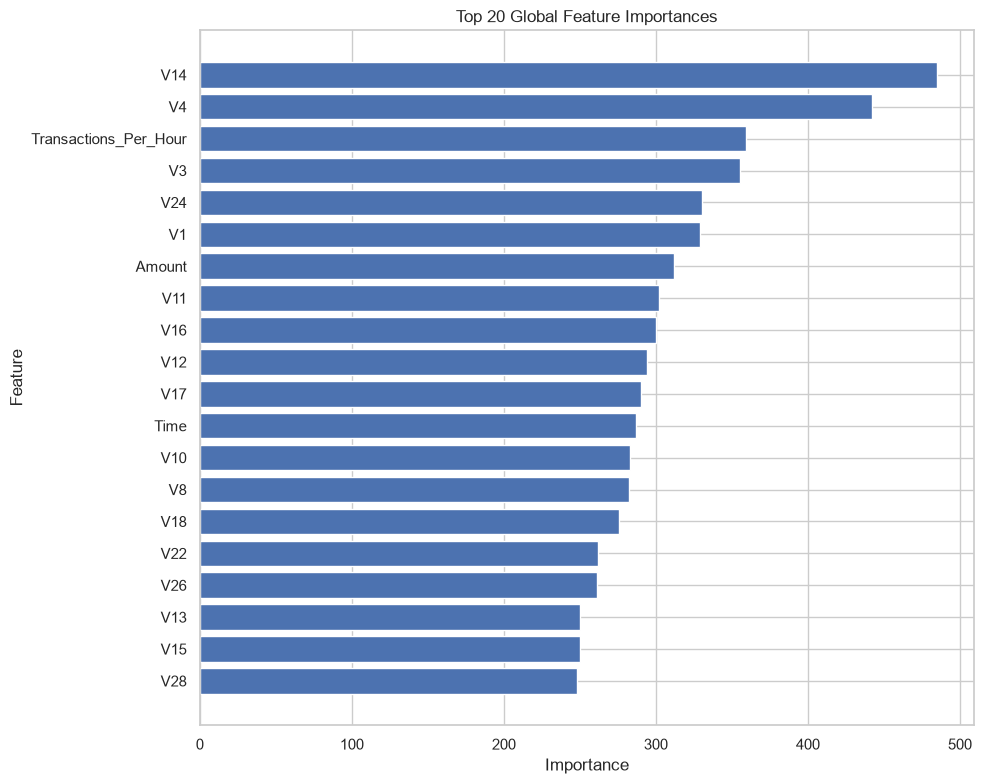

In [16]:
top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Global Feature Importances")
plt.tight_layout()
plt.show()


## 14. SHAP Global Summary

In [17]:
X_test_processed = preprocessor.transform(X_test_fe)

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_fe.index,
)

explainer = shap.TreeExplainer(fitted_model)

SHAP_SAMPLE_SIZE = min(3000, len(X_test_processed))
X_shap = X_test_processed.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print(f"SHAP sample size: {len(X_shap):,}")

SHAP sample size: 3,000


d:\4\CondaEnvs\dl\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 15. SHAP Feature Importance Table

Mean absolute SHAP value provides a global ranking of feature influence.

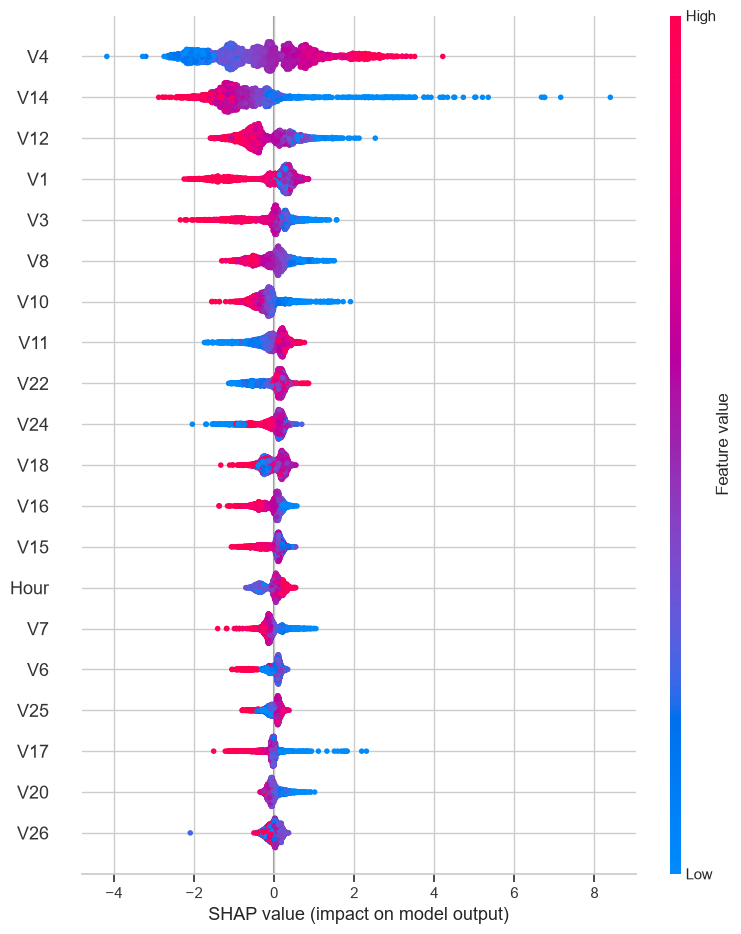

In [18]:
shap.summary_plot(
    shap_values_plot,
    X_shap,
    max_display=20,
    show=True,
)


## 16. Local SHAP Explanation

Inspect the feature contributions for the test transaction with the highest predicted fraud probability.

In [19]:
mean_abs_shap = np.abs(shap_values_plot).mean(axis=0)

shap_importance_df = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": mean_abs_shap,
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(20))


,feature,mean_abs_shap
0,V4,1.033274
1,V14,0.945497
2,V12,0.525045
3,V1,0.491814
4,V3,0.378044
5,V8,0.311526
6,V10,0.300541
7,V11,0.271264
8,V22,0.248120
9,V24,0.230768


## 17. Stage 4 Summary

The summary records the selected model, threshold, ranking metrics, operating-point metrics, and cost assumptions.

Test row index: 42769
Predicted fraud probability: 0.999978
Actual class: 1


d:\4\CondaEnvs\dl\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


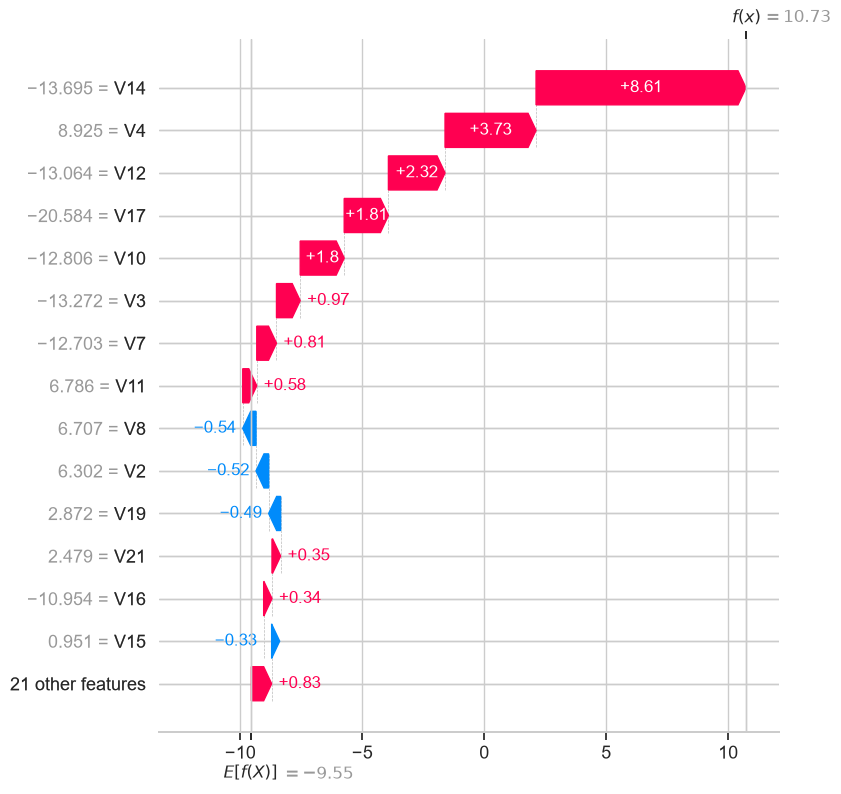

In [20]:
high_risk_test_position = int(np.argmax(test_probabilities))
high_risk_index = X_test_fe.index[high_risk_test_position]
high_risk_probability = test_probabilities[high_risk_test_position]
high_risk_actual = int(y_test.loc[high_risk_index])

print(f"Test row index: {high_risk_index}")
print(f"Predicted fraud probability: {high_risk_probability:.6f}")
print(f"Actual class: {high_risk_actual}")

local_row = X_test_processed.loc[[high_risk_index]]
local_shap_values = explainer.shap_values(local_row)

if isinstance(local_shap_values, list):
    local_shap_values_plot = local_shap_values[1]
    base_value = explainer.expected_value[1]
else:
    local_shap_values_plot = local_shap_values
    base_value = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=local_shap_values_plot[0],
        base_values=float(np.asarray(base_value).reshape(-1)[0]),
        data=local_row.iloc[0].values,
        feature_names=local_row.columns.tolist(),
    ),
    max_display=15,
)

## 18. Stage 4 summary

Record the final results below after running the notebook.

Key points:
- **Leading model:** selected using Stage 3 cross-validated Average Precision.
- **Threshold selection:** performed using out-of-fold training predictions.
- **Final threshold:** chosen using the stated business-cost assumptions.
- **Final test evaluation:** performed once on the untouched test set.
- **Interpretability:** global feature importance plus SHAP global/local explanations.

The business-cost values are project assumptions. In a real fraud system, FP/FN costs should be estimated from operational and financial consequences.

In [21]:
stage4_summary = pd.DataFrame({
    "metric": [
        "Leading model",
        "Selected threshold",
        "OOF PR-AUC",
        "Test PR-AUC",
        "Test ROC-AUC",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test Financial Cost",
        "FP Cost Assumption",
        "FN Cost Assumption",
    ],
    "value": [
        best_model_name,
        FINAL_THRESHOLD,
        oof_pr_auc,
        test_pr_auc,
        test_roc_auc,
        test_precision,
        test_recall,
        test_f1,
        test_cost,
        FP_COST,
        FN_COST,
    ],
})

display(stage4_summary)

,metric,value
0,Leading model,LightGBM — SMOTE
1,Selected threshold,0.239
2,OOF PR-AUC,0.855905
3,Test PR-AUC,0.874444
4,Test ROC-AUC,0.979296
5,Test Precision,0.769912
6,Test Recall,0.887755
7,Test F1,0.824645
8,Test Financial Cost,136.0
9,FP Cost Assumption,1.0
